<a href="https://colab.research.google.com/github/isabelacfs/estudo_de_caso_EDA_lead_scoring/blob/main/Artigo_EDA_Leadscoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudo de Caso – Análise Exploratória de Dados: Descobrindo Sinais de Compra em uma Plataforma de Cursos On-line

**Dataset:** [Leads](https://raw.githubusercontent.com/isabelacfs/MVP_Data_Analysis_Leadscoring_PUC/refs/heads/main/lead.csv)

# Descrição do Problema


O conjunto de dados "leadscoring" contém informações sobre comportamento dos leads (contatos) em uma plataforma de venda de cursos online a partir do momento que se cadastram e interagem com as páginas web.

Algumas variáveis são obtidas através de questionários, o que enriquece a base de dados a respeito do lead e seu grau de interesse nos produtos e serviços.




## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características, o objetivo é prever quais leads irão comprar ou não, a partir disso, é possível sinalizar ao time comercial quais são aqueles de maior propensão, evitando que se percam durante a jornada de compra.

O que reduz o escopo de atuação dessas equipes, possibilitando ter um time mais enxuto, além de possibilitar a personalização da comunicação para cada grupo e além de ser possível estimar a receita até antes mesmo da abertura das inscrições.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

> - **É possível identificar dos leads com maior ou menor interesse nos produtos com base nas respostas dos questionários**?

> - **É possível separar os leads em mais qualificados ou menos qualificados com base em seu comportamento no site da plataforma de cursos?**

> - **Existem perguntas ou características que dividem os leads nesse grupos distintos?**

## Seleção de Dados

O dataset se encontra na sua forma bruta e, portanto, é necessário realizar a seleção dos melhores atributos, além do tratamento de possíveis valores nulos e erros de digitação.



## Atributos do Dataset

Esta base contém os atributos como tags e lead quality, que devem ser removidos durante o tratamento, pois são campos preenchidos pelo setor comercial logo após a conversão do lead para cliente, e isso naturalmente pode resultar em *data leakage*.

O dataset lead contém 9240 amostras, com dois tipos de leads: qualificados e NÃO qualificados.


### Descrição das Variáveis do Dataset

| Atributo                                 | Descrição                                                                                  | Tipo      |
|:-------------------------------------------------------|:-------------------------------------------------------------------------------------------|:----------|
| Total Visits                                           | Total de visitas no site                                                                   | integer   |
| Total Time Spent                                       | Tempo total gasto no site (em segundos)                                                    | integer   |
| Page Views Per Visit                                   | Quantidade média de páginas vistas por visita                                              | float     |
| Lead Origin                                            | Origem do lead                                                                             | string    |
| Lead Source                                            | Canal de aquisição do lead                                                                 | string    |
| Do Not Email                                           | Flag: Não enviar e-mails (marcado para não mandar email)                                   | string    |
| Do Not Call                                            | Flag: Não ligar (marcado para não fazer ligação)                                           | string    |
| Converted                                              | Variável alvo: 1 = converteu, 0 = não converteu                                            | integer   |
| Last Activity                                          | Última atividade realizada pelo lead                                                       | string    |
| Specialization                                         | Especialização de interesse (resposta do formulário)                                       | string    |
| How did you hear about X Education                     | Como ouviu falar da gente (resposta do formulário)                                         | string    |
| What is your current occupation                        | Ocupação atual / emprego atual (resposta do formulário)                                    | string    |
| What matters most to you in choosing a course          | O que mais importa na escolha do curso (resposta do formulário)                            | string    |
| Search                                                 | Recebeu comunicação via Search? (Yes/No)                                                   | string    |
| Magazine                                               | Recebeu comunicação via Magazine? (Yes/No)                                                 | string    |
| Newspaper Article                                      | Recebeu comunicação via Newspaper Article? (Yes/No)                                        | string    |
| X Education Forums                                     | Recebeu comunicação via X Education Forums? (Yes/No)                                       | string    |
| Newspaper                                              | Recebeu comunicação via Newspaper? (Yes/No)                                                | string    |
| Digital Advertisement                                  | Recebeu comunicação via Digital Advertisement? (Yes/No)                                    | string    |
| Through Recommendations                                | Recebeu comunicação via indicação / recomendação? (Yes/No)                                 | string    |
| Receive More Updates About Our Courses                 | Deseja receber mais atualizações sobre os cursos? (Yes/No)                                 | string    |
| Tags                                                   | **REMOVIDA** – Tags do lead (risco de data leakage)                                        | string    |
| Lead Quality                                           | **REMOVIDA** – Qualidade estimada do lead (risco de data leakage)                          | string    |
| Update me on Supply Chain Content                      | Deseja atualizações sobre Supply Chain? (Yes/No)                                           | string    |
| Get updates on DM Content                              | Deseja atualizações sobre DM Content? (Yes/No)                                             | string    |
| I agree to pay the amount through cheque               | Concorda pagar via cheque? (Yes/No)                                                        | string    |
| A free copy of Mastering The Interview                 | Deseja cópia grátis do material "Mastering The Interview"? (Yes/No)                        | string    |
| Last Notable Activity                                  | Última atividade notável / importante do lead                                              | string    |

> **Observação**: Algumas variáveis foram removidas do modelo final por conterem **data leakage** (Tags e Lead Quality).

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset contendo os leads.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer # para discretizar e binizar variáveis numéricas
from scipy import stats # para calcular IQR
from sklearn.feature_selection import SelectKBest, f_classif, chi2 # Para feature selection - Seleção das K melhores variáveis
from sklearn.feature_selection import f_classif # para o teste ANOVA da Seleção Univariada

In [51]:
# instalar biblioteca scipy
!pip install scipy

In [52]:
# carregamento do dataset
PATH = "https://raw.githubusercontent.com/isabelacfs/MVP_Data_Analysis_Leadscoring_PUC/refs/heads/main/lead.csv"

In [53]:
# guardo o dataset em um dataframe
df = pd.read_csv(PATH)

In [54]:
# primeiras linhas
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity,2
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0000,0,0.0000,...,No,No,Interested in other courses,Low in Relevance,No,No,No,No,Modified,0
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0000,674,2.5000,...,No,No,Ringing,NaN,No,No,No,No,Email Opened,"2,5"
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0000,1532,2.0000,...,No,No,Will revert after reading the email,Might be,No,No,No,Yes,Email Opened,2
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0000,305,1.0000,...,No,No,Ringing,Not Sure,No,No,No,No,Modified,1
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0000,1428,1.0000,...,No,No,Will revert after reading the email,Might be,No,No,No,No,Modified,1


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset leads, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset lead possui 9240 instâncias e cada uma só pode ser de um lead qualificado ou não qualificado. Se for qualificado, a variável *Converted* é 1, se não qualificado é zero.


Temos 5 variáveis numéricas e 26 categóricas. Dentre as numéricas, Lead Number deverá ser removida  e as variáveis TotalVisits, Total Time Spent on Website e Page Views Per Visits dizem respeito ao comportamento do usário nas sessões do site. Dentre as categóricas, 16 são respostas a questionários que os leads responderam; 2 são flags internas para não ligar e não mandar email para o lead.

In [55]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 9240

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9 

In [56]:
# remoção de atributos desnecessários à modelagem
df = df.drop(['Prospect ID', 'Lead Number','Tags', 'Lead Quality', '2'], axis=1)

O gráfico de barras e o comando ```value_counts``` mostra que temos 5679 amostras de leads não qualificados (zero) e 3561 amostras de leads qualificados (1).

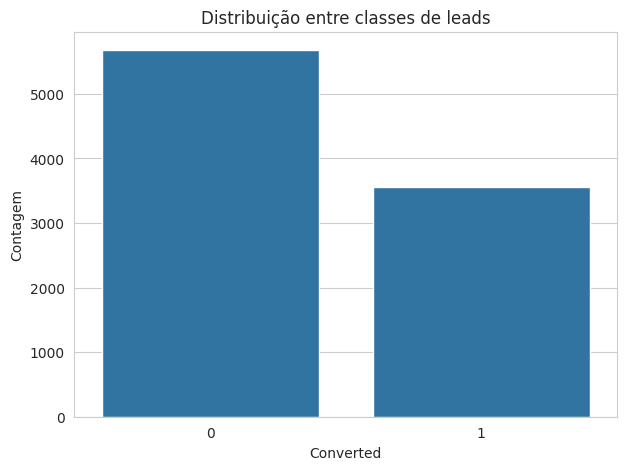

In [57]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
sns.countplot(x='Converted', data=df)
plt.title('Distribuição entre classes de leads')
plt.xlabel('Converted')
plt.ylabel('Contagem')
plt.show()

In [58]:
df['Converted'].value_counts()

,count
Converted,
0,5679
1,3561


Podemos perceber que pela plotagem das variáveis categóricas abaixo, ainda não é possível concluir visualmente qual delas tem mais peso para que o lead seja classificado com qualificado ou não qualificado (converted = 0 ou 1).

Variáveis categóricas: ['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


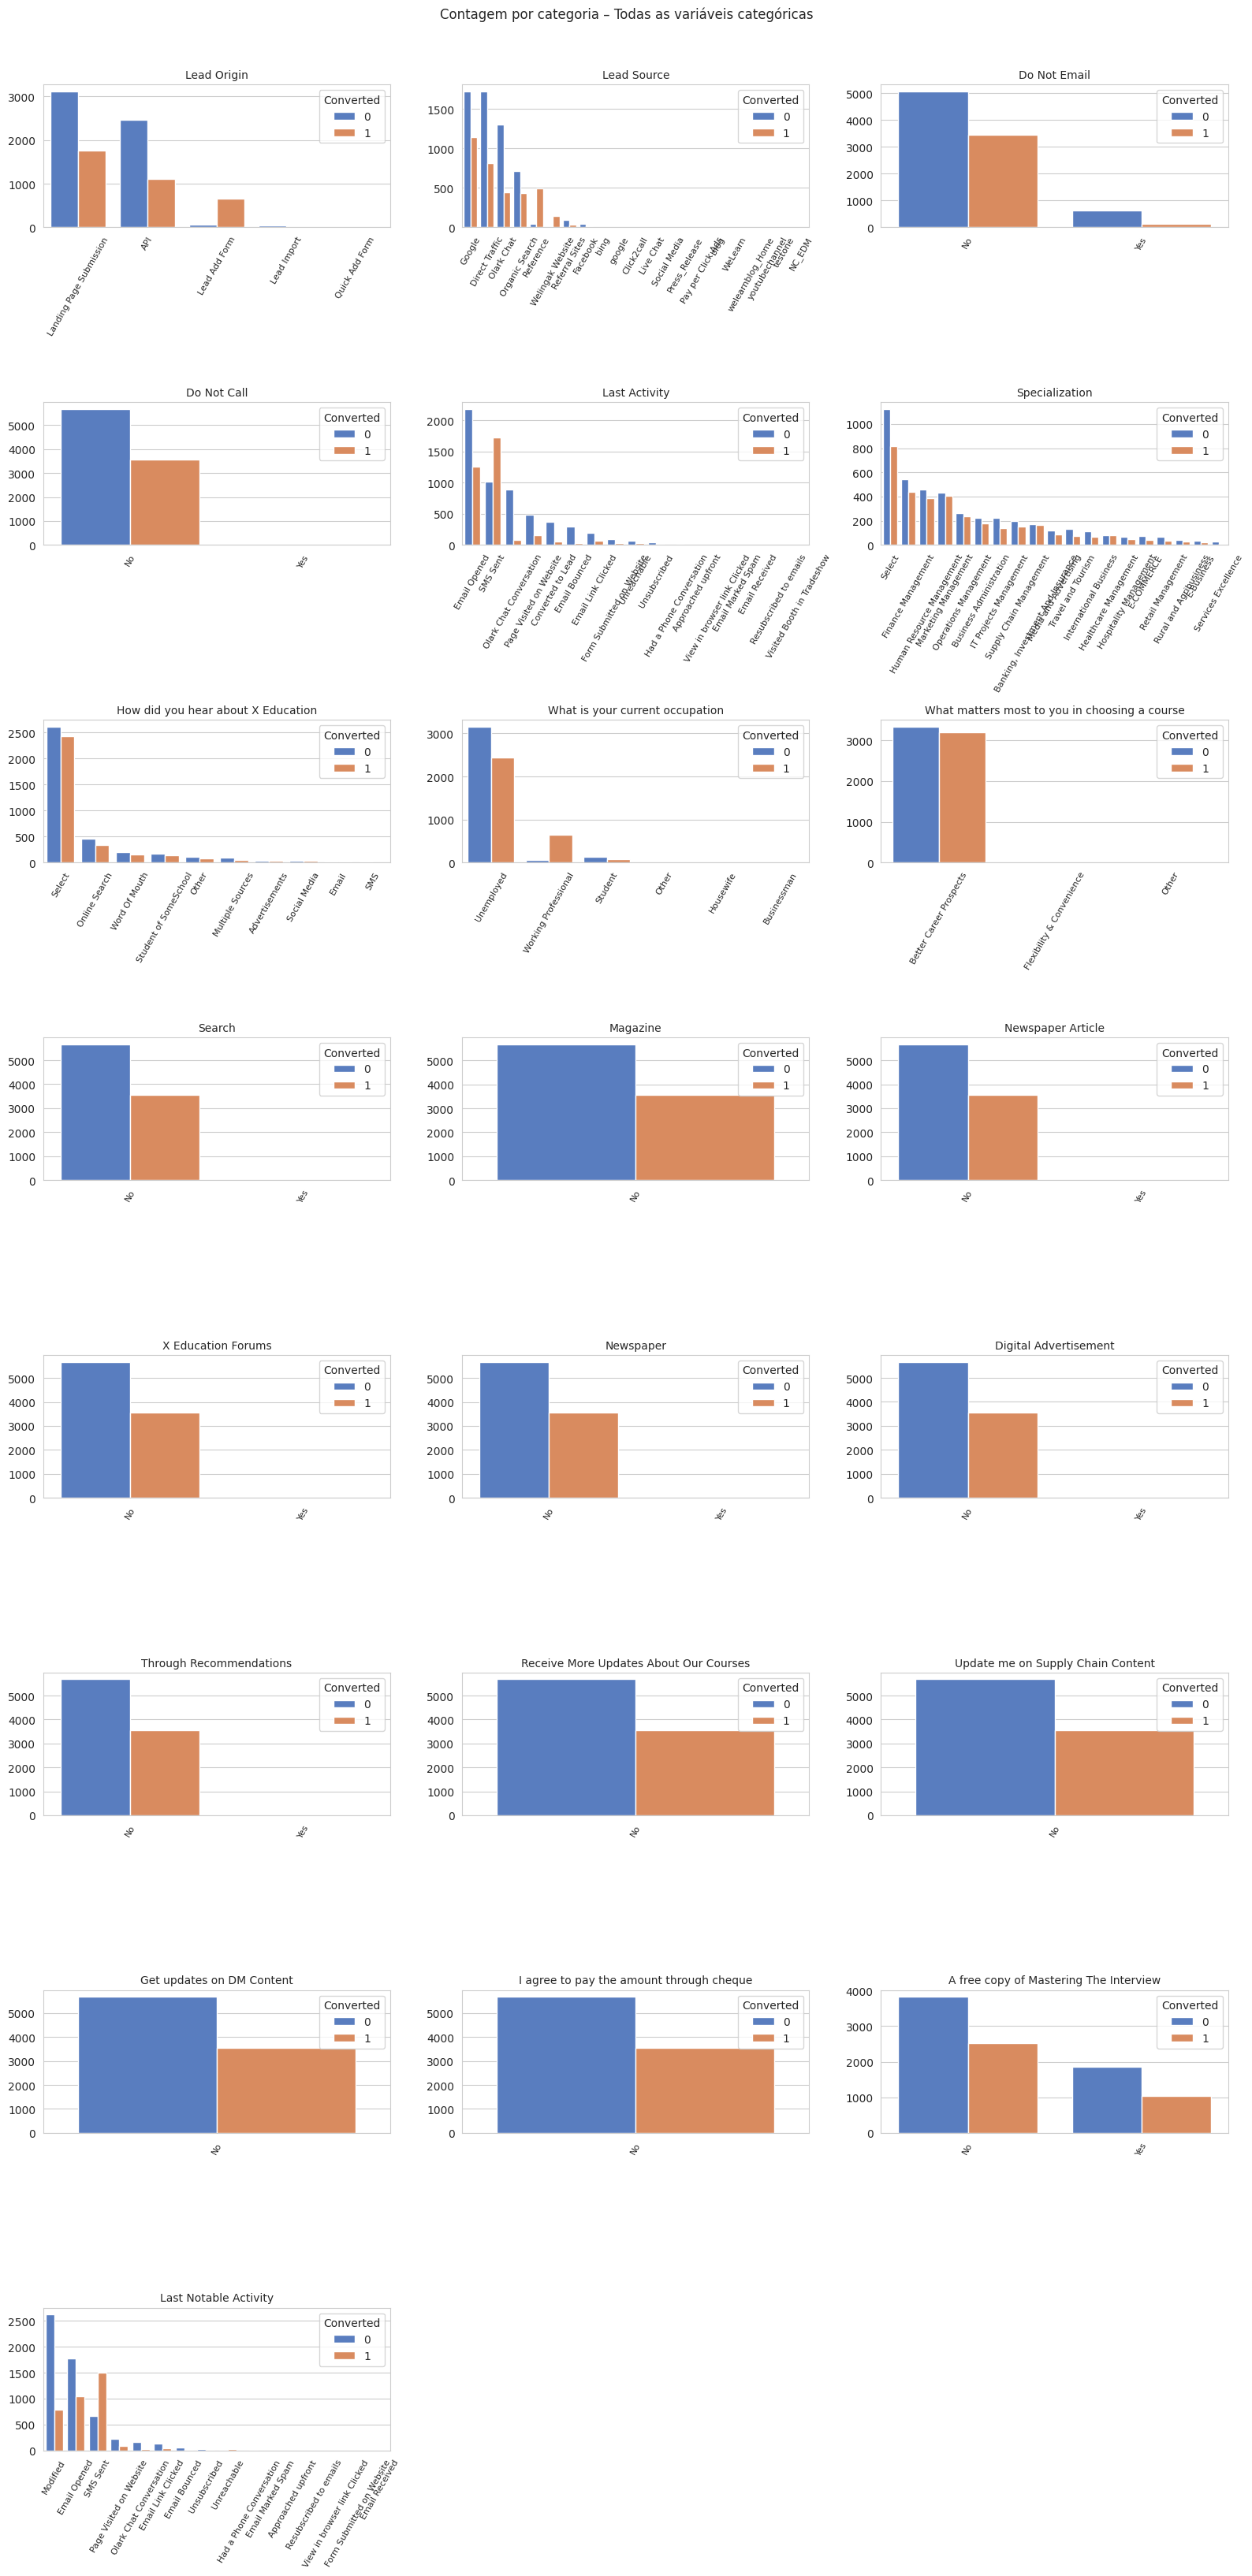

In [59]:
# Mesma identificação de colunas categóricas
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['Prospect ID', 'Lead Number', '2', 'Tags', 'Lead Quality']]
print(f"Variáveis categóricas: {cat_cols}")

fig, axes = plt.subplots(
    nrows = (len(cat_cols) + 2) // 3,
    ncols = 3,
    figsize=(16, 4 * ((len(cat_cols) + 2) // 3)),
    sharey=False
)

axes = axes.flatten()  # transforma matriz em vetor 1D

for ax, col in zip(axes, cat_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=ax,
        order=df[col].value_counts().index,
        palette='muted',
        hue='Converted'
    )
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=60, labelsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Remove subplots vazios (se houver)
for ax in axes[len(cat_cols):]:
    ax.remove()

plt.tight_layout()
plt.suptitle("Contagem por categoria – Todas as variáveis categóricas", y=1.02)
plt.show()

**Exclusão ``'Select'``**

Notamos que um item do questionário "How did you hear about X Education" tem uma frequência muito alta para a resposta "Selectt" que, no contexto, é considerado um erro de digitação no formulário. Essas ocorrências, portanto, serão excluídas, considerando também que *as classes estão bem balanceadas* entre elas, como é mostrado nas células abaixo.

In [60]:
df.loc[df['How did you hear about X Education'] == 'Select']['Converted'].value_counts()


,count
Converted,
0,2612
1,2431


<Axes: ylabel='Frequency'>

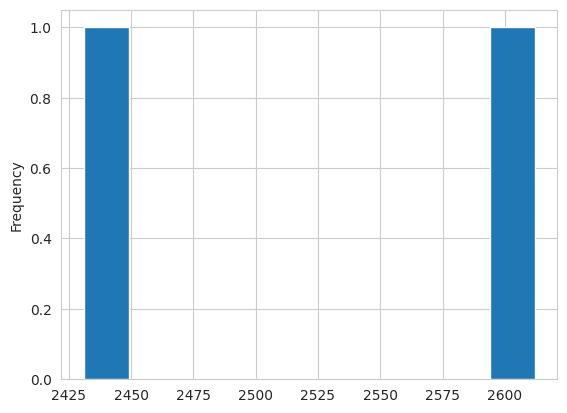

In [61]:
df.loc[df['How did you hear about X Education'] == 'Select']['Converted'].value_counts().plot.hist()

Abaixo tratamos o erro de digitação.

In [62]:
# Excluindo as linhas que contém o erro de digitação "Select"
df = df[df['How did you hear about X Education'] != 'Select']

## Estatísticas Descritivas

Na estatística descritiva podemos notar que o valor mínimo para todas as variáveis numéricas é zero.

Seria então possível se tornar aluno ou mesmo fazer uso da plataforma on-line sem nem mesmo ter efetuado uma visita à plataforma?

> ⚠️ Necessidade de checagem!

É preciso checar com a área de negócio se isso é possível pois, se não for, é necessário eliminar essas linhas. Mas, no momento, assumimos que é possível que existam valores mínimos iguais a zer.

In [63]:
# estatísticas descritivas básicas do dataset
df.describe()

,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,4197.0000,4189.0000,4197.0000,4189.0000
mean,0.2692,3.7832,489.8115,2.5835
std,0.4436,4.6255,532.2474,2.0432
min,0.0000,0.0000,0.0000,0.0000
25%,0.0000,2.0000,48.0000,1.0000
50%,0.0000,3.0000,266.0000,2.3300
75%,1.0000,5.0000,896.0000,4.0000
max,1.0000,141.0000,2226.0000,24.0000


### Média e Desvio-Padrão

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados e o desvio-padrão é uma medida de dispersão que informa quanto as observações estão disperas, ou seja, espalhadas em torno da média.

Já a mediana (50% ou segundo quartil) é uma medida de localização que divide os valores - quando ordenados - ao meio e é muito menos sensível aos outliers do que a média e, por isso, uma medida mais estável e um bom referencial para entendermos se a média foi muito distorcida por valores extremos (*outliers*).

Abaixo calculamos apenas variáveis numéricas importantes pra criação do modelo e ignoramos as demais.

Podemos observar que:

- O  total de visitas de cada usuário tem média e mediana próximas, o que indica que a média pode não estar sendo tão distorcida por outliers e que a dispersão em torno da média não é tão desproporcional em relação ao seu valor central;
- O tempo gasto no site tem média e medianas distantes - o que indica inclinação do histograma mais à direita e, desvio-padrão alto, o que pode ser um indicativo de usuários outliers. Mais à frente iremos analisar os boxplots para avaliar visualmente essa informação.
- O número de visualização de páginas visitas pelos usuários tem média e mediana bem próximas e um desvio-padrão leve, o que pode indicar que não existem anomalias no comportamento dos usuários nesse quesito.

In [64]:
# média dos atributos numéricos do dataset
colunas = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

df[colunas].describe().loc[['mean', 'std', '50%']]

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
mean,3.7832,489.8115,2.5835
std,4.6255,532.2474,2.0432
50%,3.0000,266.0000,2.3300


### Boxplots


Decidimos separar a visualização dos boxplots em leads qualificados e não qualificados.

#### *TotalVisits*

Podemos observar que há visitantes que superam bastante o total de visitas do site e nos leva acreditar que são pessoas realmente interessadas nos produtos e podem ser leads com grande potencial de compra. Mas quando plotamos o gráfico acima separando por grupo (converteu = qualificado e não converteu = não qualficado), percebemos que:

 - nos dois grupos existem outliers e, especialmente no grupo de quem não converteu, existem aqueles que chegam a 140 visitas ao site, enquanto que a média de visitas é 3,7.
 - a média de visitas dos que converteram é levemente acima dos que não converteram e, então esta variável pode influenciar na conversão do lead.

 > Ação: os valores de outliers deverão ser substituídos pela mediana, uma vez que a média (para mais) está sendo distorcida pela presença destes outliers.

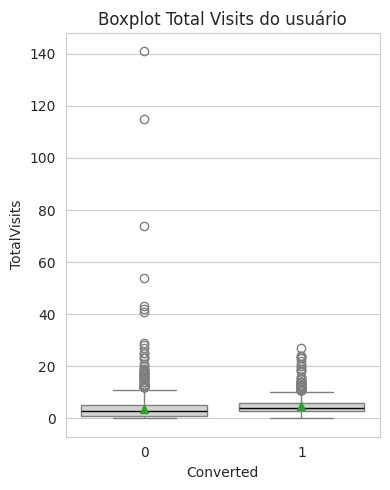

In [65]:
plt.figure(figsize=(4, 5))
sns.set_style("whitegrid")           # grade leve de fundo

sns.boxplot(
    data=df,
    x='Converted',
    y='TotalVisits',
    color='lightgray',
    showmeans=True,
    # meanline=True,                    # linha horizontal curta no lugar do ponto
    meanprops={"color": "darkred", "linewidth": 2},
    medianprops={"color": "black"},
)

plt.title("Boxplot Total Visits do usuário")
plt.tight_layout()
plt.show()

#### *Total Time Spent on Website*

Pelo gráfico, observamos que a média do tempo total gasto no site do grupo que converteu (1) é mais alta e tem mais amplitude do que os não converteram (0), podendo ser um indicativo de que o tempo que o lead passa no site é uma variável importante para o modelo e, por isso, investigaremos essa correlação mais adiante.

Também podemos observar outliers entre aqueles que não converteram. Uma hipóteses para isso é que esses leads deixaram a sessão do navegador aberta enquanto faziam outra coisa e, por isso, valores tão altos, o que não é objeto de estudo deste trabalho.

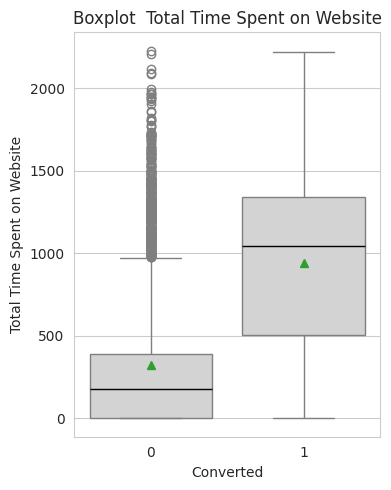

In [66]:
plt.figure(figsize=(4, 5))

sns.boxplot(
    data=df,
    x='Converted',
    y='Total Time Spent on Website',
    color='lightgray',
    showmeans=True,
    # meanline=True,                    # linha horizontal curta no lugar do ponto
    meanprops={"color": "darkred", "linewidth": 2},
    medianprops={"color": "black"},
)

plt.title("Boxplot  Total Time Spent on Website")
plt.tight_layout()
plt.show()

#### *Page Views Per Visit*

No gráfico abaixo, podemos ver que aqueles que converteram visitaram em média um número maior de páginas (em cada visita) do que aqueles que não converteram. Portanto, o número de páginas do site também pode ser indicativo de que o lead pode converter.

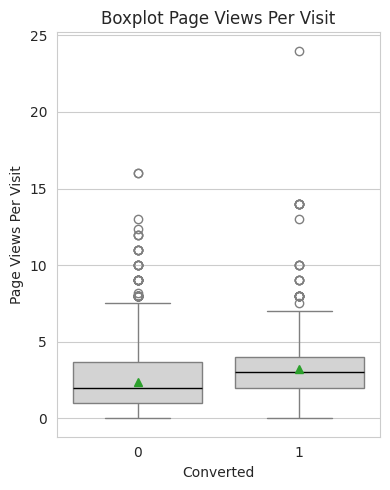

In [67]:
# Page Views Per Visit

plt.figure(figsize=(4, 5))

sns.boxplot(
    data=df,
    x='Converted',
    y='Page Views Per Visit',
    color='lightgray',
    showmeans=True,
    # meanline=True,                    # linha horizontal curta no lugar do ponto
    meanprops={"color": "darkred", "linewidth": 2},
    medianprops={"color": "black"},
)

plt.title("Boxplot Page Views Per Visit")
plt.tight_layout()
plt.show()

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *TotalVisits*


Podemos ver que não há variabilidade demais (espalhamento em torno da média) e, por isso, o gráfico se concentra mais ou menos em torno da média e da mediana, mas a cauda longa para direita mostra que existem observações que puxam a média para cima, o que pode ser observado também nos boxplot com presença de outliers.

Isso indica que a maioria dos usuários visita o site mais ou menos a mesma quantidade de vezes, com exceção dos outliers, que formaram essa cauda longa para a direita. Uma hipótese para isso é que os leads consomem conteúdo no site e estudam através dele; ou que bots ou computadores infectados com vírus fiquem acessando o site, o que está fora do escopo deste trabalho.

Devemos tratar os outliers para melhorar a capacidade de prever a probabilidade compra dos nossos futuros compradores mas também recomendar a instalação ferramentas de análises que gravam as interações e checar se são de fato bots.

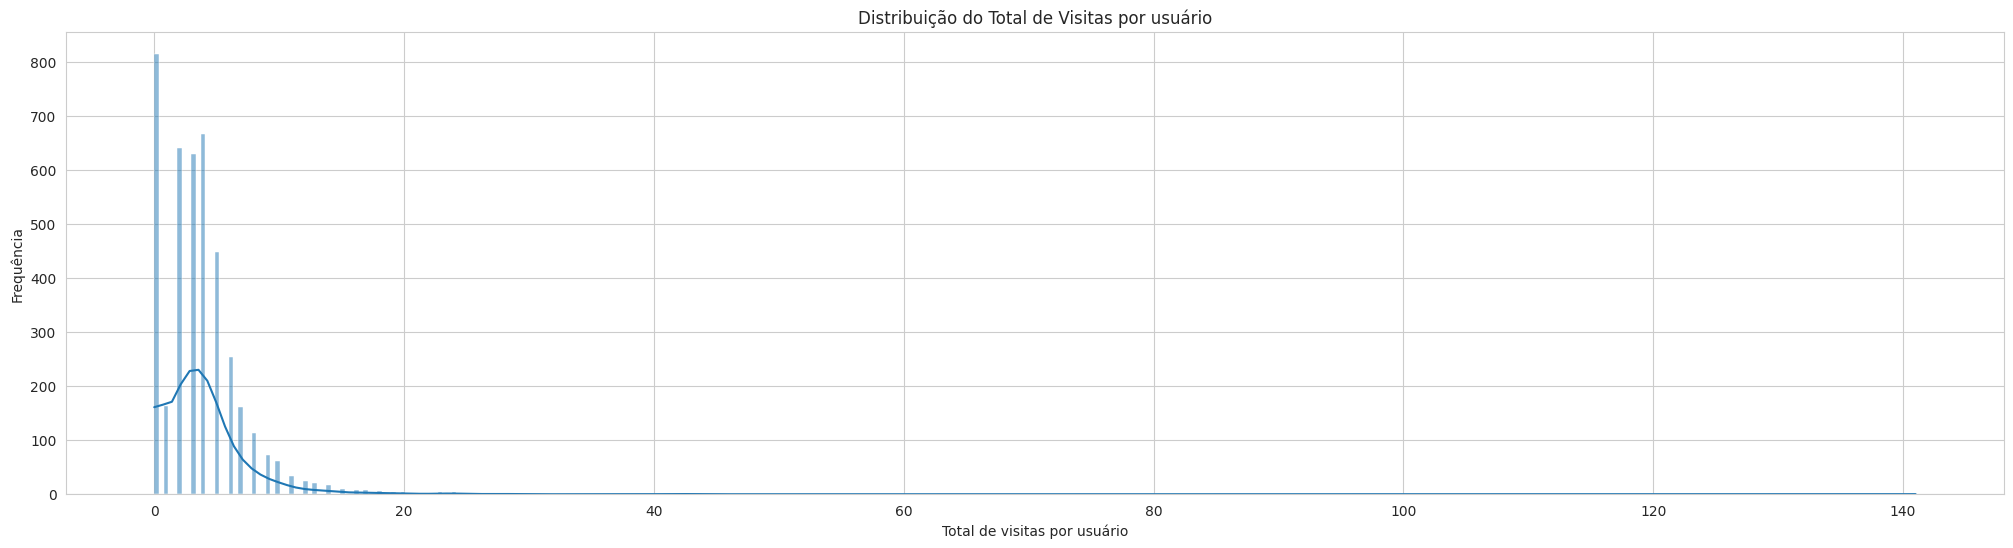

In [68]:
plt.figure(figsize=(25, 6))
# Histograma do Distribuição do Total de Visitas
sns.histplot(df['TotalVisits'], kde=True)
plt.title('Distribuição do Total de Visitas por usuário')
plt.xlabel('Total de visitas por usuário')
plt.ylabel('Frequência')
plt.show()

### *Total Time Spent on Website*

No gráfico de densidade abaixo conseguimos perceber com mais detalhe o fato de que esta variável tem um alto desvio-padrão, ou seja, alta variabilidade nas observações, o que também é demonstrado nas estatísticas descritivas acima. Podemos ver com clareza que também a média é "puxada" para a direita e, portanto, a cauda longa mais à direita da curva, enquanto a mediana permanece insensível à presença deles.

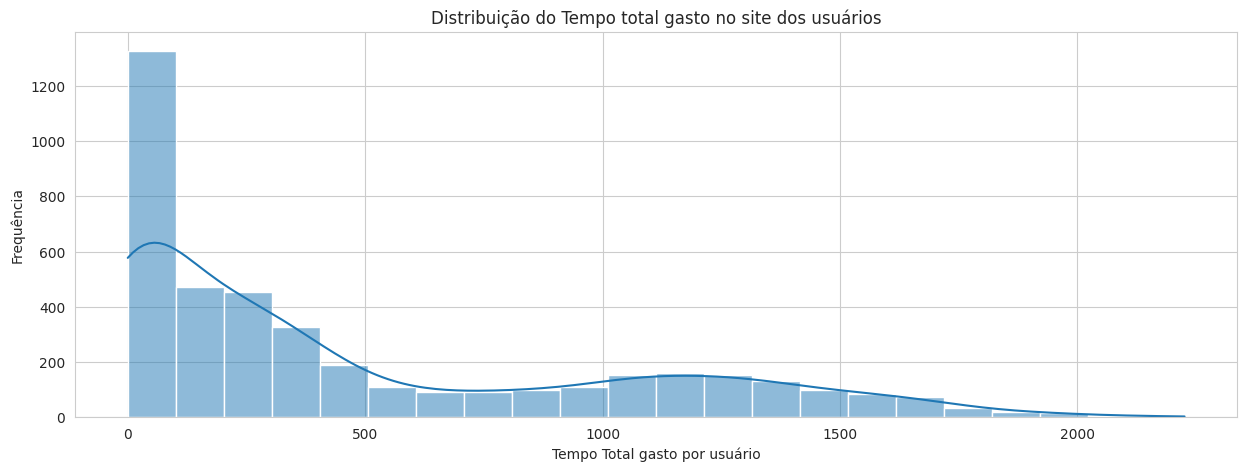

In [69]:
plt.figure(figsize=(15, 5))
# Histograma do Tempo total gasto no site dos usuários
sns.histplot(df['Total Time Spent on Website'], kde=True)
plt.title('Distribuição do Tempo total gasto no site dos usuários')
plt.xlabel('Tempo Total gasto por usuário')
plt.ylabel('Frequência')
plt.show()

### *Page Views Per Visit*

Podemos ver abaixo que o fato de existir outliers não gerou um alto-desvio padrão e por este motivo o gráfico de densidade não se mostrou tão espalhado em torno da média que, por sua vez, ficou próxima da mediana.

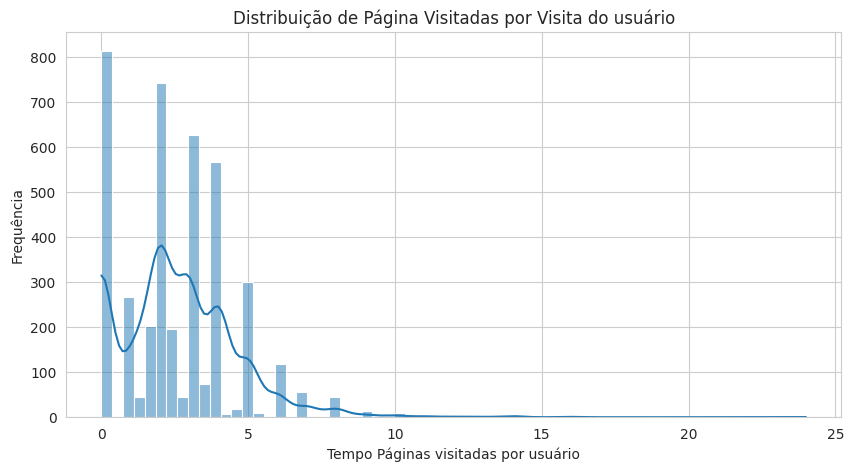

In [70]:
plt.figure(figsize=(10, 5))
# Histograma de páginas por visita do usuário
sns.histplot(df['Page Views Per Visit'], kde=True)
plt.title('Distribuição de Página Visitadas por Visita do usuário')
plt.xlabel('Tempo Páginas visitadas por usuário')
plt.ylabel('Frequência')
plt.show()

# Tratamento de Outliers e Nulos

As variáveis numéricas com valores nulos são Total de visitas e Visualizações de páginas por visita. A seguir tratamos tanto os outliers quanto os valores nulos.

Tendo visto a distribuição dos dados, podemos tomar uma decisão e tratar os outliers e valores nulos de cada variável numérica de forma que a base de dados consiga refletir observações que não distorçam totalmente a média.

Antes de decidir pela exclusão destas observações, iremos avaliar se existe uma medida de posição que possa substituir esses valores.

Checamos a inclinação e todos os valores estão acima de 0,5 (e abaixo de (-0,5) e nos informa que curva de distribuição não é simétrica, havendo inclinação para direita ou para esquerda, por conta dos outliers, o que coincide com a informação visual das caudas vistas nas distribuições das variáveis total visit, total time spent on website e page views per visit!

Por isso,substituiremos os outliers e os valores nulos pela MEDIANA, por ser uma medida de posição menos sensíveis às anomalias e vieses.

 A seguir, vamos calcular os outliers: valores maiores do que 1,5x o interquartil ou menores do que -1,5x o interquartil.



#### **Substituições dos nulos**


In [71]:
# preenchendo com fillna os nulos de total visits e page views per visit
df['TotalVisits'] = df['TotalVisits'].fillna(df['TotalVisits'].median()) # total visits
df['Page Views Per Visit'] = df['Page Views Per Visit'].fillna(df['Page Views Per Visit'].median()) # page views per visit


In [72]:
# checando total de nulos em todas as variáveis numéricas após preencher
df[['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']].isnull().sum()

,0
TotalVisits,0
Total Time Spent on Website,0
Page Views Per Visit,0


In [73]:
# calculando inclinação do gráfico de densidade
print(df['TotalVisits'].skew())
print(df['Total Time Spent on Website'].skew())
print(df['Page Views Per Visit'].skew())

11.83949573329298
0.9820883294459075
1.351932338999729


In [74]:
# Calculamos os interquartis de cada variável (IQR)
iqr_totvis = stats.iqr(df['TotalVisits'], nan_policy='omit') * 1.5 # interquartil de totalvisits vezes 1,5
iqr_timespent = stats.iqr(df['Total Time Spent on Website'], nan_policy='omit') * 1.5 # interquartil de total time spent on website vezes 1,5
iqr_pages = stats.iqr(df['Page Views Per Visit'], nan_policy='omit') * 1.5 # interquartil de page views per visit vezes 1,5

# Vamos dar uma olhada nos valores no limite superior dos outliers de cada variável
# print(iqr_totvis, iqr_timespent, iqr_pages)
print(f'OUTLIERS \n total visits > {iqr_totvis} serão considerados outliers.')
print(f' total time spent > {iqr_timespent} serão considerados outliers.')
print(f' page views per visit > {iqr_pages} serão considerados outliers.')


OUTLIERS 
 total visits > 4.5 serão considerados outliers.
 total time spent > 1272.0 serão considerados outliers.
 page views per visit > 4.5 serão considerados outliers.


#### **Substituições dos outliers**

In [75]:
# Fazendo substituições pela mediana
# Substitui outliers do total de visitas
df.loc[((df['TotalVisits'] > iqr_totvis) | (df['TotalVisits'] < -(iqr_totvis))), 'TotalVisits'] = df['TotalVisits'].median()

# Substitui outliers do Tempo total gasto no site
df.loc[((df['Total Time Spent on Website'] > iqr_timespent) | (df['Total Time Spent on Website'] < -(iqr_timespent))), 'Total Time Spent on Website'] = df['Total Time Spent on Website'].median()

# Substitui outliers de Visualizações de páginas por visita ao site
df.loc[((df['Page Views Per Visit'] > iqr_pages) | (df['Page Views Per Visit'] < -(iqr_pages))), 'Page Views Per Visit'] = df['Page Views Per Visit'].median()


# ✪ ANOVA (Antes do pré-processamento)
Vou aplicar teste Anova aqui para testar se a variâncias das variáveis numéricas são iguais às variâncias do nosso target, dito isto, estamos testando se as variabilidades das variáveis independentes afetam a variável dependente, na presença das demais.

In [76]:
X_anova = df[['TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit']].dropna()
y_anova = df['Converted']
f_statistic, p_values = f_classif(X_anova, y_anova)

Como podemos perceber os p-valores são extremamente pequenos (abaixo de 0,05), ou seja, há uma minúscula probabilidade de que a variabilidade destas variáveis não afetem a variabilidade da nossa variável-alvo.
Em outras palavras, elas são altamente significativas para nossa variável-alvo.

E se, ainda assim, os intervalos forem grandes e não nos ajude a identificar quem é quem, podemos ser ainda mais específicos para entender que tipo de usuários têm mais relação com a atividade de compra, em outras palavras, conseguimos ir mais fundo pra entender qual lead é mais quente, foi o que fizemos [aqui](#discretizacao)!

In [77]:
p_values

array([6.75562047e-058, 3.17812108e-153, 2.77069094e-049])

In [78]:
# Checando os intervalos destas variáveis
df[['TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit']].describe().loc[['min', 'max']]

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
min,0.0000,0.0000,0.0000
max,4.0000,1272.0000,4.5000


## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

É importante não apenas checar se há correlação entre as variáveis independentes e a variável dependente, mas também checar se existe correlação entre as variáveis independentes para previnirmos a questão da multicolinearidade durante a modelagem.

Percebemos correlações positivas, porém fracas. Por isso, avançaremos um pouco mais na análise estatística para entender se há influência real na nossa variável compra ou não compra.

In [79]:
# Matriz de correlação
print("\nMatriz de Correlação:")
COLS = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Converted']
df[COLS].corr()


Matriz de Correlação:


,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Converted
TotalVisits,1.0000,0.4136,0.9035,0.2439
Total Time Spent on Website,0.4136,1.0000,0.3813,0.3908
Page Views Per Visit,0.9035,0.3813,1.0000,0.2249
Converted,0.2439,0.3908,0.2249,1.0000


## Mapa de calor
A matriz de correlação nos mostra correlações positivas entre a variável-alvo Converted e total de visitas, entre Converted e tempo total gasto no site, mas ainda muito baixas.

Enquanto que, entre Converted e visualizações de página por visita, é negativa mas baixa também.

Através da matriz de correlação não conseguimos concluir quão influentes (sem a presença das demais) são as variáveis independentes com relação à variável dependente.

Por isso, a seleção de atributos e testes de signficância são importantes para batermos o martelo sobre a inclusão ou exclusão delas, considerando também o princípio da parsimônia.

Abaixo podemos perceber que existe uma correlação positiva forte (maior que 0,50) entre o total de visitas e de visualizações de páginas por visita, o que faz total sentido para usuários de um site, uma vez que quanto mais visitas fazem, mais páginas visualizam.

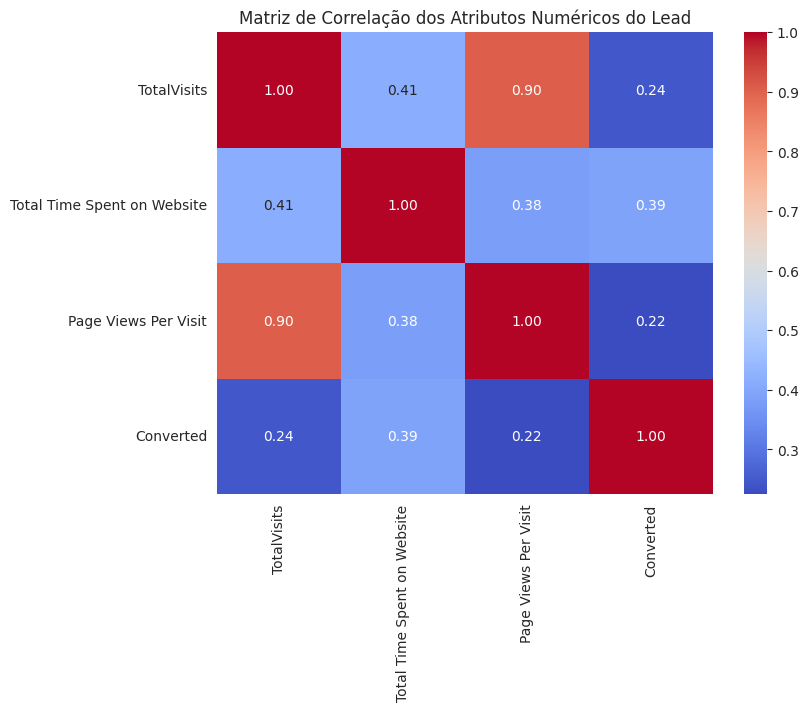

In [80]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df[COLS].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação dos Atributos Numéricos do Lead')
plt.show()

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

Nesta etapa escolhemos lidar com variáveis binárias pois o nosso futuro modelo deverá classificar os leads em qualificados e não qualificados (1 e 0) e por isso as variáveis, tanto numéricas quanto categóricas, deverão seguir o mesmo padrão da variável-alvo.
</br></br>

**Pré-processamento das variáveis numéricas**

As variáveis numéricas contínuas serão **discretizadas** (intervalos) e depois transformadas em atributos binários, assumindo 1 quando a observação pertencer àquele intervalo e zero quando não.


**Pré-processamento das variáveis categóricas**

Transformar as variáveis categóricas (respostas dos questionários) em binárias, criando um atributo binário por categoria e excluindo o primeiro para evitar multicolinearidade entre as novas features criadas.


## *Discretização das variáveis numéricas*

Esmiuçamos melhor as variáveis sobre o comportamento do lead ao <a name="discretizacao">discretizá-las</a> e depois transformando-as em categóricas binárias, assim podemos aplicar outro teste, podendo ser mais precisos quanto aos usuários com comportamentos mais preditivos.

In [81]:
# Separando as variáveis numéricas contínuas
# Discretizar todas as variáveis numéricas
df['TotalVisits'] = pd.cut(df['TotalVisits'], bins=4)
df['Total Time Spent on Website'] = pd.cut(df['Total Time Spent on Website'], bins=4)
df['Page Views Per Visit'] = pd.cut(df['Page Views Per Visit'], bins=4)

## *Binnização das variáveis categóricas*

In [82]:
# # Transformar todas variáveis em binárias, incluindo as numéricas
# df_binned = pd.get_dummies(df.drop(['Converted'], axis=1), # Exceto a variável-alvo
#                             dtype=float, # seta o tipo retornado
#                             drop_first=True) # evitar multicolinearidade

In [83]:
# Transformar todas variáveis em binárias, incluindo as numéricas
df_binned = pd.get_dummies(df.drop(['Converted'], axis=1), # Exceto a variável-alvo
                            dtype=float, # seta o tipo retornado
                            # drop_first=True
                           ) # evitar multicolinearidade

In [84]:
# Olhada no dataset original 26 features
print('Quantidade de caraterísticas no dataset original: ', df.columns.shape[0])

Quantidade de caraterísticas no dataset original:  26


In [85]:
# Olhada no dataset binarizado 92 features
print('Quant. de caraterísticas no dataset binarizado só com as variáveis independentes: ', df_binned.columns.shape[0])

Quant. de caraterísticas no dataset binarizado só com as variáveis independentes:  120


In [86]:
# Olhada em todas as features geradas após as transformações
df_binned.columns

Index(['Lead Origin_API', 'Lead Origin_Landing Page Submission',
       'Lead Origin_Lead Add Form', 'Lead Origin_Lead Import',
       'Lead Origin_Quick Add Form', 'Lead Source_Click2call',
       'Lead Source_Direct Traffic', 'Lead Source_Facebook',
       'Lead Source_Google', 'Lead Source_NC_EDM',
       ...
       'Last Notable Activity_Email Received',
       'Last Notable Activity_Form Submitted on Website',
       'Last Notable Activity_Had a Phone Conversation',
       'Last Notable Activity_Modified',
       'Last Notable Activity_Olark Chat Conversation',
       'Last Notable Activity_Page Visited on Website',
       'Last Notable Activity_Resubscribed to emails',
       'Last Notable Activity_SMS Sent', 'Last Notable Activity_Unreachable',
       'Last Notable Activity_Unsubscribed'],
      dtype='object', length=120)

In [87]:
# Separar features (X) e target (y)
X = df_binned
y = df['Converted'].values

#### **Holdout**

Antes de dividir os dados de treino e teste, verificamos que através do gráfico de barras abaixo que as classes estão desbalanceadas. Para garantir que seja preservada a proporção entre elas durante a divisão do dataset em treino e teste. Em seguida, iremos utilizar a divisão estratificada.

<Axes: xlabel='Converted'>

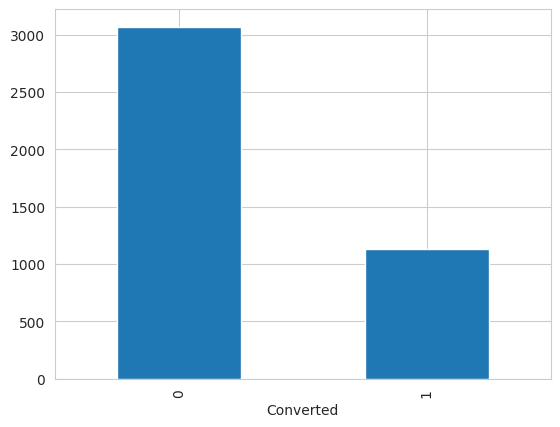

In [88]:
df['Converted'].value_counts().plot.bar()

In [89]:
# Dividindo dados de treino e teste utilizando divisão estratificada indicando o target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [90]:
# Dimensões dos dados de treino e teste
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (2937, 120)
Dimensões de X_test: (1260, 120)
Dimensões de y_train: (2937,)
Dimensões de y_test: (1260,)


## Normalização

Pulamos a etapa da normalização pois ela escala os dados para um intervalo fixo, geralmente entre 0 e 1, o que já fizemos na etapa de transformar todas as variáveis em valores binários,  como podemos observar na saída do código abaixo.

In [91]:
print('X_TRAIN: Valor máximo:', X_train.max(),
      '\t Valor mínimo:', X_train.min())
print('Y_TRAIN Valor máximo:', y_train.max(),
      '\t Valor mínimo:', y_train.min())
print('X_TEST: Valor máximo:', X_test.max(),
      '\t Valor mínimo:', X_test.min())
print('Y_TEST Valor máximo:', y_test.max(),
      '\t         Valor mínimo:', y_test.min())


X_TRAIN: Valor máximo: Lead Origin_API                                 1.0000
Lead Origin_Landing Page Submission             1.0000
Lead Origin_Lead Add Form                       1.0000
Lead Origin_Lead Import                         1.0000
Lead Origin_Quick Add Form                      0.0000
                                                 ...  
Last Notable Activity_Page Visited on Website   1.0000
Last Notable Activity_Resubscribed to emails    0.0000
Last Notable Activity_SMS Sent                  1.0000
Last Notable Activity_Unreachable               1.0000
Last Notable Activity_Unsubscribed              1.0000
Length: 120, dtype: float64 	 Valor mínimo: Lead Origin_API                                 0.0000
Lead Origin_Landing Page Submission             0.0000
Lead Origin_Lead Add Form                       0.0000
Lead Origin_Lead Import                         0.0000
Lead Origin_Quick Add Form                      0.0000
                                                 ... 

## Padronização


A <a id="padronizacao">padronização</a> (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [92]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

Para realizar a padronização, o modelo irá aprender a média e desvio-padrão da matriz x_train e x_test.

In [93]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train) #aprendendo os padrões de x_train
X_train_standardized = scaler_std.transform(X_train) # padroniza X_train
# Usa a média e o desvio padrão aprendidos de X_train também em X_test
X_test_standardized = scaler_std.transform(X_test) # padroniza X_test

In [94]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

Dando uma olhada nos dados padronizados, percebemos alguns números negativos, o que irá afetar no teste <a id="chi-quadrado"> logo adiante</a>



In [95]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
df_standardized.head()


Primeiras 5 linhas dos dados padronizados (treino):


,Lead Origin_API,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Click2call,Lead Source_Direct Traffic,Lead Source_Facebook,Lead Source_Google,Lead Source_NC_EDM,...,Last Notable Activity_Email Received,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed
0,1.3336,-1.3238,-0.0369,-0.0452,0.0000,-0.0185,-0.5178,-0.0452,1.0456,0.0000,...,0.0000,-0.0185,-0.0320,-0.8626,-0.1608,-0.2028,0.0000,-0.4562,-0.0489,-0.0763
1,1.3336,-1.3238,-0.0369,-0.0452,0.0000,-0.0185,-0.5178,-0.0452,1.0456,0.0000,...,0.0000,-0.0185,-0.0320,1.1593,-0.1608,-0.2028,0.0000,-0.4562,-0.0489,-0.0763
2,-0.7498,0.7554,-0.0369,-0.0452,0.0000,-0.0185,1.9312,-0.0452,-0.9563,0.0000,...,0.0000,-0.0185,-0.0320,1.1593,-0.1608,-0.2028,0.0000,-0.4562,-0.0489,-0.0763
3,1.3336,-1.3238,-0.0369,-0.0452,0.0000,-0.0185,-0.5178,-0.0452,-0.9563,0.0000,...,0.0000,-0.0185,-0.0320,1.1593,-0.1608,-0.2028,0.0000,-0.4562,-0.0489,-0.0763
4,1.3336,-1.3238,-0.0369,-0.0452,0.0000,-0.0185,-0.5178,-0.0452,-0.9563,0.0000,...,0.0000,-0.0185,-0.0320,1.1593,-0.1608,-0.2028,0.0000,-0.4562,-0.0489,-0.0763


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


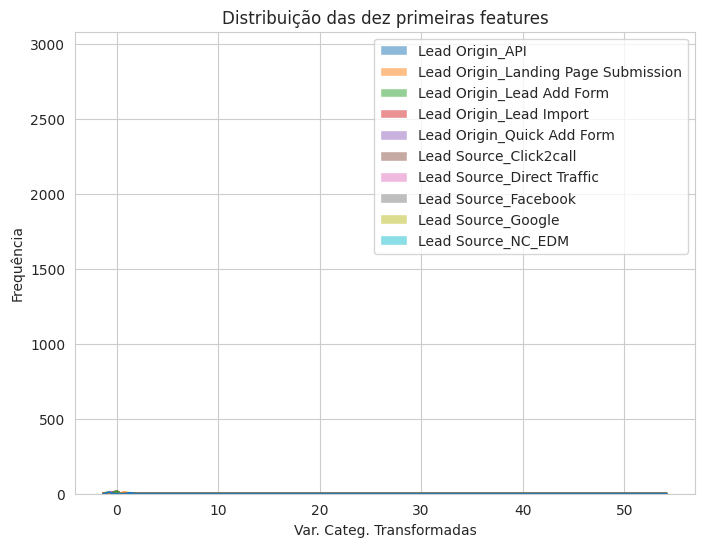

In [47]:
# Visualização da distribuição após a padronização (exemplo para dez características)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized.iloc[:, 0:10], kde=True)
plt.title('Distribuição das dez primeiras features')
plt.xlabel('Var. Categ. Transformadas')
plt.ylabel('Frequência')
plt.show()

Podemos perceber abaixo pelo gráfico de densidade que o nosso objetivo de padronizar os dados foi atingido com sucesso, pois as médias foram centralizadas próximo a zero e porque mantivemos a mesma forma da distribuição original, gráficos esparsados.

## Outras Transformações e Etapas de Pré-Processamento




### ANOVA e Chi-Quadrado

Como nosso dataset após o pré-processamento resultou em cerca de 92 features, pelo princípio da parsimônia, idealmente seria incluir no modelo a seleção das características mais discrimativas, deixando o modelo mais robusto e evitando overfitting.

Nas próximas células exploramos o dataset com *SelectKBest* para entender quais são elas, ao indicar score_func igual a ``f_classif`` para indicar que estamos considerando o teste F de ANOVA e ``chi2`` para o [teste Chi-Quadrado](#chi-quadrado)





Esse teste é baseado em análise de variância e calcula a significância - através do teste F - que mede a dependência entre as variáveis independente e a variável-alvo. Quanto mais alta for essa dependência, maior será o score de classificação.

In [48]:
# dando uma olhada no número de features (dataset de treino)
df_standardized.shape[1]

120

### Comparação entre testes

Passamos X_train ao invés de df_standardized pois o teste Chi-Quadrado não aceita valores negativos nem nulos que porventura foram gerados durante a [padronização](#padronizacao).







In [49]:
X = X_train.astype(int) # convertendo x_train para inteiro
y = y_train
# Supondo que:
# X  → seu DataFrame já com One-Hot Encoding (todas colunas 0/1)
# y  → sua variável target (categórica)

# 1. Calcula scores com f_classif (ANOVA)
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X, y)
scores_f = pd.Series(selector_f.scores_).fillna(0) # Preenche NaN com 0

# 2. Calcula scores com chi2
selector_chi = SelectKBest(score_func=chi2, k='all')
selector_chi.fit(X, y)
scores_chi = pd.Series(selector_chi.scores_).fillna(0) # Preenche NaN com 0

# 3. Cria DataFrame de comparação
comparison = pd.DataFrame({
    'feature_index': range(X.shape[1]),
    'feature_name': X.columns,                    # nomes das features
    'f_classif_score': scores_f,
    'chi2_score': scores_chi,
    'f_classif_rank': scores_f.rank(ascending=False, method='min').astype(int),
    'chi2_rank': scores_chi.rank(ascending=False, method='min').astype(int)
})

# Formata para não usar notação científica
pd.set_option('display.float_format', '{:.4f}'.format)

# Ordena pelo score do chi2 (mais recomendado no seu caso)
comparison_sorted = comparison.sort_values(by='chi2_score', ascending=False)

# Mostra as Top 20 features com os dois scores e ranks
print("=== Comparação Top 20 Features (ordenado por chi2) ===")
display(comparison_sorted[['feature_name',
                         'chi2_score', 'chi2_rank',
                         'f_classif_score', 'f_classif_rank']].head(50))

# Diferença de ranking (quanto maior, mais discordância)
comparison['rank_diff'] = abs(comparison['f_classif_rank'] - comparison['chi2_rank'])
print("\n=== Features com maior discordância entre os dois métodos ===")
display(comparison.sort_values(by='rank_diff', ascending=False)[['feature_name',
                                                              'chi2_rank',
                                                              'f_classif_rank',
                                                              'rank_diff']].head(15))


=== Comparação Top 20 Features (ordenado por chi2) ===


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  4   9  12  22  43  48  91  96 101 102 103 104 110 116] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,feature_name,chi2_score,chi2_rank,f_classif_score,f_classif_rank
117,Last Notable Activity_SMS Sent,433.3309,1,636.6552,1
88,What matters most to you in choosing a course_...,298.8076,2,548.4020,2
49,Last Activity_SMS Sent,290.1699,3,444.9969,3
34,"Total Time Spent on Website_(954.0, 1272.0]",235.9431,4,289.4968,4
87,What is your current occupation_Working Profes...,201.7808,5,225.3339,6
86,What is your current occupation_Unemployed,156.7748,6,246.1630,5
27,"TotalVisits_(-0.004, 1.0]",127.3216,7,176.1288,9
35,"Page Views Per Visit_(-0.0045, 1.125]",120.1625,8,170.7186,10
113,Last Notable Activity_Modified,115.0931,9,215.3081,7
46,Last Activity_Olark Chat Conversation,103.9485,10,125.9630,15



=== Features com maior discordância entre os dois métodos ===


,feature_name,chi2_rank,f_classif_rank,rank_diff
25,Do Not Call_No,101,55,46
23,Do Not Email_No,53,20,33
99,Through Recommendations_No,102,83,19
97,Digital Advertisement_No,102,83,19
94,X Education Forums_No,102,83,19
92,Newspaper Article_No,102,83,19
105,A free copy of Mastering The Interview_No,80,62,18
42,Last Activity_Email Opened,60,50,10
31,"Total Time Spent on Website_(-1.272, 318.0]",16,8,8
68,Specialization_Rural and Agribusiness,99,105,6


Como podemos ver, não há tantas discrepâncias dentre os scores do teste Chi-quadrado ou do Teste F-ANOVA e, por isso, poderíamos ter escolhido apenas um deles para prosseguir na seleção de features.



A feature mais bem classificada é ``Last Notable Activity_SMS Sent`` em ambos os testes e indica a última atividade importante feita pelo lead. Possivelmente porque alguém muito interessado em adquirir um produto da nossa plataforma de cursos queira tirar dúvidas antes de efetuar a compra, o que nos leva a notar sua similaridade com terceira característica mais bem classificada, ``Last Activity_SMS Sent`` do ranking.
> Recomendação: Como elas, aparentemente são um espelho uma da outra, é prudente retirar do dataset a segunda para evitarmos multicolinearidade.



Dentre as mais importantes, uma variável numérica importante, que foi discretizada ``Total Time Spent on Website_(848.0, 1272.0]``, indicando que quem passou entre *848 e 1272 segundos* tem forte relação com o nosso target.



Não surpreendentemente, o lead que preencheu como desempregado (``What is your current occupation_Unemployed``), é uma das mais significativas nos dois rankings, tanto quanto aqueles que responderam estar empregados(``What is your current occupation_Working Professional``), também se mostram propensos a comprar, ambos se mostram propensos à compra.


# Respondendo nossas hipóteses
### ... *e alguns comentários!*

Uma vez que boa parte do dataset eram respostas a questionários (variáveis categóricas), tornando mais difícil a interpretação visual da influência delas para que o lead se qualificado ou desqualificado e, mesmo as variáveis numéricas, que apresentaram correlações (positivas porém fracas), num primeiro momento não foram conclusiva quanto a sua influência para variabilidade do nosos target.

Em resumo, nem a análise exploratória dos dados dos questionários nem mesmo do comportamento do lead no site foram visualmente conclusivos e, por isso, as transformações das variáveis, o tratamento de nulos e de outliers e os scores gerados nos testes Chi-Quadrado e F-ANOVA foram imprescindíveis para termos:

- maior granularidade dos dados;
- facilitar os insights;
- gerar recomendações para a continuação desse trabalho no âmbito do aprendizado supervisionada;
- melhorias contínuas no tratamento e aquisição dos dados.

Portanto, vamos retomar as nossas hipóteses!









### Hipótese 1

> É possível identificar dos leads com maior ou menor interesse nos produtos com base nas respostas dos **questionários**?

Com base apenas numa análise visual dos histogramas, gráfico de barras, boxplots e matriz de correlação, não foi posssível detectar facilmente quais eram mais preditoras, mas ao exploramos a última sessão com teste F de ANOVA e CHI-QUADRADO, conseguimos identificar as mais importantes.

Sem isso, não estaria evidente que muitas perguntas como "ocupação do lead" ou "onde você ouvir falar da X Educação" estão dentre as mais significativas.

*Logo, podemos afirmar que *sim*, as respostas aos questionários tem forte relação com a variável-alvo.*

### Hipótese 2

> É possível separar os leads em mais qualificados ou menos qualificados com base em seu **comportamento** no site da plataforma de cursos?

O comportamento do site foi modelado em três variáveis (tempo total gasto no site, número visualizações de páginas e total de visitas), as quais apresentam correlações positivas mas fracas (< 0.5), ou seja, um pequeno indício de que poderiam ter relação com o evento de compra do lead.

Durante o pré-processamento detectamos quais características são mais signficativas - e que não foi possível detalhar com clareza nas etapas anteriores.


```
Contudo, alguns intervalos chamam mais atenção!
```


- Ter gasto mais tempo no site: passar de 15 a 20 minutos (``Total Time Spent on Website_(954.0, 1272.0]``)) é mais significativo do que ter passado entre 10 minutos e 15 minutos  (``Total Time Spent on Website_(636.0, 954.0]``)


- Ter visitado a plataforma de cursos um total de 2 a 3 vezes( ``TotalVisits_(2.4, 3.2]``) é melhor do que quando ele visita 3 a 4 vezes, talvez porque se concentrem mais em pontos específicos do conteúdo.


- Ter visualizado de 4 a 5 vezes é mais significativo do que 2 a 3 vezes, talvez porque **usuários que visitam mais páginas mas que se concentram nos detalhes que irão influenciar na sua compra;

> Recomendação: instalar ferramentas analíticas que gravam as interações dos usuários no site e observar se há diferença entre os dois grupos.



Podemos concluir que *sim*, tanto o *comportamento* do lead no site e suas respostas aos questionários tem bastante relação com o fato de ele ser um lead propenso à compra.

## Hipótese 3

> Existem perguntas ou características que dividem os leads nesse grupos distintos?

Não há características que saltam aos olhos rapidamente para que possamos dividir com clareza os grupos em leads com alta probabilidade de comprar ou não. O que podemos perceber é que não existe uma característica única mas um conjunto de variáveis com os quais o lead interage que influenciam e deixam o trabalho de análise mais complexo e não muito óbvio a priori.

Portanto, a fase de pré-processamento, além da transformação das variáveis e os testes estatísticos, facilitaram bastante a compreensão das interações das variáveis que contribuem para o lead comprar ou não o produto.

# Conclusão

A análise exploratória e estudo das relações entre as variáveis independentes e a variável dependente foram imprescindíveis para enxergarmos além de narrativas enviesadas como:

> *"Quem passa mais tempo no site da plataforma é sempre um lead com bom potencial de compra"*;

> *"Lead desempregado não é um potencial comprador"*;

> *"Quanto mais páginas ele visualiza por visita, maior o interesse no produto"*.

No entanto, a variável com mais alto score - em ambos os testes - apontam que, o fato de o próprio lead ter interagido com a empresa mandando um SMS mostra que o **lead qualificado não é simplesmente um ser passivo** mas que interage com os pontos de contato; e que não é um "ser" a ser interrogado, mas alguém que interroga.

A posição desta variável deixa claro que combinação entre manter uma estratégia de **comunicação com via de mão dupla** e ofercer mais canais de comunicação que atendam às solicitações do público-alvo são imprescindíveis para empresas que desejam se sobressair, especialmente num ambiente já dominado pelas automações e aplicações de inteligência artificial.

Poderíamos ser levados também a concluir que
> "*Fazer os usuários passarem mais tempo no site deve ser a próxima North Star Metric* do time de marketing"

seria algo correto, mas toda nossa análise exploratória aponta que existe uma correlação - e não relação de implicação -  entre o tempo gasto no site e a conversão do lead em cliente. O que quer dizer que iniciativas para manter as pessoas por mais tempo nessas plataformas podem até aumentar artificialmente essas métricas mas não influenciaria a variável-alvo.

Em outras palavras, o lead não terá mais vontade de comprar o produto pelo fato de ser forçado a ficar mais tempo no site. Pelo contrário, isso gera fricção e desgasta a marca.

A Análise Exploratória de Dados também apontou que os esforços de marca, a comunicação de mão dupla e a relação com o cliente, geram maior engajamento e percepção de valor, a ponto de influenciar no comportamento de compra; algo que fica comprovado quando combinamos a origem do lead - ou seja, pesquisou a marca no Google(``lead_source_google``) de forma espontânea e a resposta de ``how did you hear about x education_online_search`` ser através de pesquisa on-line.


Temos, portanto, que três hipóteses levantadas foram validadas, além das que já foram levantadas acima:



1. **É possível identificar dos leads com maior ou menor interesse nos produtos com base nas respostas dos questionários?** Sim, as respostas aos questionários tem forte relação com a variável-alvo.

2. **É possível separar os leads em mais qualificados ou menos qualificados com base em seu comportamento no site da plataforma de cursos?** Sim, tanto o comportamento do lead no site e suas respostas aos questionários tem bastante relação com o fato de ele ser um lead propenso à compra.

3. **Existem perguntas ou características que dividem os leads nesse grupos distintos?** Não há características que saltam aos olhos rapidamente para que possamos dividir com eficácia os grupos em leads que irão converter e os que não